# Bài tập - Nhóm 14
Phân loại ảnh MNIST — Softmax, MLP, CNN, ViT (builtin & tự xây), CNN→Transformer, LSTM/GRU



## 📌 README

### 1) Chạy theo thứ tự
1. Chạy cell **Setup** (cài thư viện).
2. Chạy cell **Imports & config** (đặt `DEVICE='cuda'`).
3. Chạy cell **Load MNIST** để tải dữ liệu và tạo `train/val/test_loader`.
4. Chạy cell **Models** và **Training/Eval** để định nghĩa kiến trúc + vòng lặp huấn luyện.
5. Chạy cell **Quick experiments** để train hàng loạt mô hình và tạo bảng so sánh.

### 2) Kết quả
Mỗi lần chạy `train_and_report(...)` sẽ tạo thư mục `results/<run_name>/` gồm:
- `history.json`: train_loss/val_loss/val_acc theo epoch
- `best.pt`: checkpoint tốt nhất theo val_acc
- `learning_curves.png`: biểu đồ loss/accuracy
- `confusion_matrix.png`: ma trận nhầm lẫn
- `test_metrics.json`: test_loss, test_acc

Sau khi chạy tổng hợp sẽ có `results/summary.csv`.

### 3) Chạy từng mô hình riêng
```python
run_dir, metrics = train_and_report('cnn', epochs=10, lr=1e-3)
run_dir, metrics = train_and_report('vit', epochs=15, lr=1e-3)
```
Model hỗ trợ: `softmax`, `mlp`, `cnn`, `vit`, `vit_scratch`, `cnn_trans`, `rnn_lstm`, `rnn_gru`.


In [ ]:
import sys, subprocess
def _pip(pkg):
    if subprocess.call([sys.executable, '-m', 'pip', 'show', pkg.split('==')[0]], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL) != 0:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
for p in ['torch', 'torchvision', 'matplotlib', 'pandas', 'numpy']:
    _pip(p)
print('Hoàn tất cài đặt.')


Hoàn tất cài đặt.


In [ ]:
import math, json, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda'
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('Thiết bị:', DEVICE)


Thiết bị: cuda


In [ ]:
IMG_SIZE = 28
BATCH_SIZE = 256
VAL_RATIO = 0.1
tfm = transforms.ToTensor()
train_full = datasets.MNIST('./data', train=True, download=True, transform=tfm)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=tfm)
val_len = int(len(train_full)*VAL_RATIO); train_len = len(train_full)-val_len
train_ds, val_ds = random_split(train_full, [train_len, val_len])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False)
IN_CH, NUM_CLASSES = 1, 10
len(train_ds), len(val_ds), len(test_ds)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.97MB/s]


(54000, 6000, 10000)

In [ ]:
def plot_history(history, run_dir):
    epochs = history['epoch']
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(epochs, history['train_loss'], label='Huấn luyện')
    ax[0].plot(epochs, history['val_loss'], label='Xác thực')
    ax[0].set_title('Hàm mất mát theo epoch')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
    ax[1].plot(epochs, history['val_acc'], label='Độ chính xác (Validation)')
    ax[1].set_title('Độ chính xác theo epoch')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Độ chính xác'); ax[1].legend()
    fig.tight_layout()
    out = Path(run_dir)/'learning_curves.png'
    fig.savefig(out, dpi=150); plt.show()

def confusion_matrix(targets, preds, num_classes=10):
    import numpy as np
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(targets, preds): cm[t, p] += 1
    return cm

def plot_confusion_matrix(cm, labels=None, title='Ma trận nhầm lẫn', run_dir='.'):
    import numpy as np
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax)
    ax.set_title(title); ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
    if labels is not None:
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha='center', va='center', fontsize=7)
    fig.tight_layout()
    out = Path(run_dir)/'confusion_matrix.png'
    fig.savefig(out, dpi=150); plt.show()


In [ ]:
def run_train(model, train_loader, val_loader, optimizer, epochs=5, device=DEVICE, grad_clip=None, run_dir='results/tmp'):
    Path(run_dir).mkdir(parents=True, exist_ok=True)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    history = { 'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': [] }
    best_acc, best_state = -1, None
    for ep in range(1, epochs+1):
        model.train(); t0 = time.time(); running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            if grad_clip is not None: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running += loss.item()*y.size(0)
        train_loss = running/len(train_loader.dataset)
        model.eval(); vloss = 0.0; correct = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                vloss += loss.item()*y.size(0)
                pred = logits.argmax(1)
                correct += (pred==y).sum().item()
        vloss /= len(val_loader.dataset)
        vacc = correct/len(val_loader.dataset)
        history['epoch'].append(ep); history['train_loss'].append(train_loss); history['val_loss'].append(vloss); history['val_acc'].append(vacc)
        (Path(run_dir)/'history.json').write_text(json.dumps(history, ensure_ascii=False, indent=2))
        if vacc>best_acc: best_acc=vacc; best_state={k:v.cpu() for k,v in model.state_dict().items()}
        t1=time.time()
        print(f"Epoch {ep:02d}: train_loss={train_loss:.4f} val_loss={vloss:.4f} val_acc={vacc:.4f} time={t1-t0:.1f}s")
    if best_state is not None:
        torch.save({'model_state_dict': best_state, 'val_acc': best_acc}, Path(run_dir)/'best.pt')
    return history

def evaluate(model, data_loader, device=DEVICE, ckpt_path=None):
    if ckpt_path and Path(ckpt_path).exists():
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state['model_state_dict'])
    model.to(device); model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss=0.0; total_correct=0; preds=[]; targets=[]
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item()*y.size(0)
            p = logits.argmax(1)
            total_correct += (p==y).sum().item()
            preds.append(p.cpu().numpy()); targets.append(y.cpu().numpy())
    total_loss/=len(data_loader.dataset); acc=total_correct/len(data_loader.dataset)
    import numpy as np
    preds = np.concatenate(preds); targets = np.concatenate(targets)
    cm = confusion_matrix(targets, preds, num_classes=10)
    return { 'loss': float(total_loss), 'acc': float(acc), 'confusion_matrix': cm }


In [ ]:
# Softmax Regression
class SoftmaxRegression(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10):
        super().__init__(); self.net = nn.Sequential(nn.Flatten(), nn.Linear(in_ch*img_size*img_size, num_classes))
    def forward(self, x): return self.net(x)

# MLP (2 tầng ẩn)
class MLP(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10, hidden=(512,256)):
        super().__init__()
        in_dim=in_ch*img_size*img_size
        self.net=nn.Sequential(nn.Flatten(), nn.Linear(in_dim, hidden[0]), nn.ReLU(True), nn.Linear(hidden[0], hidden[1]), nn.ReLU(True), nn.Linear(hidden[1], num_classes))
    def forward(self, x): return self.net(x)

# CNN đơn giản
class SimpleCNN(nn.Module):
    def __init__(self, in_ch=1, num_classes=10, width=64):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(in_ch, width, 3, padding=1), nn.BatchNorm2d(width), nn.ReLU(True),
            nn.Conv2d(width, width, 3, padding=1), nn.BatchNorm2d(width), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(width, width*2, 3, padding=1), nn.BatchNorm2d(width*2), nn.ReLU(True),
            nn.MaxPool2d(2)
        )
        self.head=nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(width*2, num_classes))
    def forward(self, x):
        return self.head(self.features(x))

# ViT builtin
class PatchEmbed(nn.Module):
    def __init__(self, in_ch=1, patch_size=4, d_model=192):
        super().__init__(); self.proj=nn.Conv2d(in_ch, d_model, kernel_size=patch_size, stride=patch_size)
    def forward(self, x): x=self.proj(x); B,D,H,W=x.shape; return x.flatten(2).transpose(1,2),(H,W)

class ViTBuiltin(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10, patch_size=4, d_model=192, depth=6, heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_embed=PatchEmbed(in_ch, patch_size, d_model)
        enc_layer=nn.TransformerEncoderLayer(d_model, heads, int(d_model*mlp_ratio), dropout, batch_first=True, norm_first=True)
        self.encoder=nn.TransformerEncoder(enc_layer, num_layers=depth)
        self.cls=nn.Parameter(torch.zeros(1,1,d_model))
        self.pos=nn.Parameter(torch.zeros(1, 1+(img_size//patch_size)*(img_size//patch_size), d_model))
        self.norm=nn.LayerNorm(d_model); self.head=nn.Linear(d_model, num_classes)
        nn.init.trunc_normal_(self.pos, std=0.02); nn.init.trunc_normal_(self.cls, std=0.02)
    def forward(self, x):
        x,_=self.patch_embed(x); B,N,D=x.shape
        cls=self.cls.expand(B,-1,-1); x=torch.cat([cls,x],1)
        x=x+self.pos[:,:x.size(1),:]
        x=self.encoder(x)
        x=self.norm(x[:,0])
        return self.head(x)

# TransformerEncoder
class MultiheadSelfAttention(nn.Module):
    def __init__(self, d_model=192, num_heads=3, dropout=0.0):
        super().__init__(); assert d_model%num_heads==0
        self.h=num_heads; self.dk=d_model//num_heads
        self.q=nn.Linear(d_model,d_model); self.k=nn.Linear(d_model,d_model); self.v=nn.Linear(d_model,d_model); self.o=nn.Linear(d_model,d_model); self.drop=nn.Dropout(dropout)
    def forward(self, x): # B,N,D
        B,N,D=x.shape
        q=self.q(x).view(B,N,self.h,self.dk).transpose(1,2)
        k=self.k(x).view(B,N,self.h,self.dk).transpose(1,2)
        v=self.v(x).view(B,N,self.h,self.dk).transpose(1,2)
        att=(q@k.transpose(-2,-1))/math.sqrt(self.dk); att=att.softmax(-1); att=self.drop(att)
        out=att@v; out=out.transpose(1,2).contiguous().view(B,N,D)
        return self.o(out)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=192, heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__(); self.n1=nn.LayerNorm(d_model); self.attn=MultiheadSelfAttention(d_model, heads, dropout); self.d1=nn.Dropout(dropout); self.n2=nn.LayerNorm(d_model)
        self.mlp=nn.Sequential(nn.Linear(d_model,int(d_model*mlp_ratio)), nn.GELU(), nn.Dropout(dropout), nn.Linear(int(d_model*mlp_ratio), d_model), nn.Dropout(dropout))
    def forward(self, x): x=x+self.d1(self.attn(self.n1(x))); x=x+self.mlp(self.n2(x)); return x

class TransformerEncoderScratch(nn.Module):
    def __init__(self, d_model=192, depth=6, heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__(); self.blocks=nn.ModuleList([TransformerEncoderBlock(d_model,heads,mlp_ratio,dropout) for _ in range(depth)])
    def forward(self, x):
        for b in self.blocks: x=b(x)
        return x

class ViTScratch(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10, patch_size=4, d_model=192, depth=6, heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__(); self.patch=PatchEmbed(in_ch, patch_size, d_model); self.enc=TransformerEncoderScratch(d_model, depth, heads, mlp_ratio, dropout)
        self.cls=nn.Parameter(torch.zeros(1,1,d_model)); self.pos=nn.Parameter(torch.zeros(1,1+(img_size//patch_size)*(img_size//patch_size), d_model))
        self.norm=nn.LayerNorm(d_model); self.head=nn.Linear(d_model, num_classes); nn.init.trunc_normal_(self.pos,std=0.02); nn.init.trunc_normal_(self.cls,std=0.02)
    def forward(self, x): x,_=self.patch(x); B,N,D=x.shape; cls=self.cls.expand(B,1,D); x=torch.cat([cls,x],1); x=x+self.pos[:,:x.size(1),:]; x=self.enc(x); x=self.norm(x[:,0]); return self.head(x)

# CNN → Transformer hybrid
class CNNBackbone(nn.Module):
    def __init__(self, in_ch=1, width=48):
        super().__init__(); self.net=nn.Sequential(
            nn.Conv2d(in_ch, width, 3, padding=1), nn.ReLU(),
            nn.Conv2d(width, width, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(width, width*2, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
    def forward(self, x): return self.net(x)

class CNNTransformerHybrid(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10, d_model=192, heads=3, layers=4):
        super().__init__(); self.backbone=CNNBackbone(in_ch, width=d_model//4); self.proj=nn.Conv2d(d_model//2, d_model, 1)
        enc=nn.TransformerEncoderLayer(d_model, heads, d_model*4, 0.1, batch_first=True, norm_first=True); self.encoder=nn.TransformerEncoder(enc, layers)
        self.pool=nn.AdaptiveAvgPool1d(1); self.head=nn.Linear(d_model, num_classes)
    def forward(self, x): x=self.backbone(x); x=self.proj(x); B,D,H,W=x.shape; x=x.flatten(2).transpose(1,2); x=self.encoder(x); x=x.transpose(1,2); x=self.pool(x).squeeze(-1); return self.head(x)

# RNN LSTM/GRU
class ImageSequence(nn.Module):
    def __init__(self, mode='rows'):
        super().__init__(); assert mode in {'rows','cols','patches'}; self.mode=mode
    def forward(self, x):
        B,C,H,W=x.shape
        if self.mode=='rows': return x.permute(0,2,1,3).contiguous().view(B,H,C*W)
        if self.mode=='cols': return x.permute(0,3,1,2).contiguous().view(B,W,C*H)
        ph=pw=4; assert H%ph==0 and W%pw==0
        x=x.unfold(2,ph,ph).unfold(3,pw,pw).contiguous().view(B,C,(H//ph)*(W//pw),ph*pw).transpose(1,2).contiguous().view(B,(H//ph)*(W//pw),C*ph*pw)
        return x

class RNNClassifier(nn.Module):
    def __init__(self, in_ch=1, img_size=28, num_classes=10, hidden=256, layers=2, cell='lstm', seq_mode='rows'):
        super().__init__(); self.seq=ImageSequence(seq_mode)
        input_size = in_ch*img_size if seq_mode in {'rows','cols'} else in_ch*16
        self.rnn = nn.LSTM(input_size, hidden, num_layers=layers, batch_first=True) if cell=='lstm' else nn.GRU(input_size, hidden, num_layers=layers, batch_first=True)
        self.head=nn.Linear(hidden, num_classes)
    def forward(self, x): x=self.seq(x); out,_=self.rnn(x); out=out[:,-1]; return self.head(out)


In [ ]:
def build_model(name):
    if name=='softmax': return SoftmaxRegression(IN_CH, IMG_SIZE, NUM_CLASSES)
    if name=='mlp': return MLP(IN_CH, IMG_SIZE, NUM_CLASSES)
    if name=='cnn': return SimpleCNN(IN_CH, NUM_CLASSES, width=64)
    if name=='vit': return ViTBuiltin(IN_CH, IMG_SIZE, NUM_CLASSES, patch_size=4, d_model=192, depth=6, heads=3)
    if name=='vit_scratch': return ViTScratch(IN_CH, IMG_SIZE, NUM_CLASSES, patch_size=4, d_model=192, depth=6, heads=3)
    if name=='cnn_trans': return CNNTransformerHybrid(IN_CH, IMG_SIZE, NUM_CLASSES, d_model=192, heads=3, layers=4)
    if name=='rnn_lstm': return RNNClassifier(IN_CH, IMG_SIZE, NUM_CLASSES, hidden=256, layers=2, cell='lstm', seq_mode='rows')
    if name=='rnn_gru': return RNNClassifier(IN_CH, IMG_SIZE, NUM_CLASSES, hidden=256, layers=2, cell='gru', seq_mode='cols')
    raise ValueError('Model không hỗ trợ')

def train_and_report(model_name, epochs=5, lr=1e-3):
    run_dir = RESULTS / f"mnist_{model_name}_{int(time.time())}"
    model = build_model(model_name)
    optim_ = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    print(f'\n===== Huấn luyện {model_name} (epochs={epochs}) =====')
    history = run_train(model, train_loader, val_loader, optim_, epochs=epochs, device=DEVICE, run_dir=str(run_dir))
    plot_history(history, run_dir)
    ckpt = run_dir/'best.pt'
    metrics = evaluate(model, test_loader, device=DEVICE, ckpt_path=str(ckpt) if ckpt.exists() else None)
    (run_dir/'test_metrics.json').write_text(json.dumps({'loss': metrics['loss'], 'acc': metrics['acc'], 'confusion_matrix': metrics['confusion_matrix'].tolist() if hasattr(metrics['confusion_matrix'], 'tolist') else metrics['confusion_matrix']}, ensure_ascii=False, indent=2))
    plot_confusion_matrix(metrics['confusion_matrix'], labels=[str(i) for i in range(10)], run_dir=str(run_dir))
    return run_dir, metrics



===== Huấn luyện softmax (epochs=3) =====
Epoch 01: train_loss=0.8898 val_loss=0.5151 val_acc=0.8745 time=8.5s
Epoch 02: train_loss=0.4419 val_loss=0.4027 val_acc=0.8945 time=6.4s
Epoch 03: train_loss=0.3711 val_loss=0.3624 val_acc=0.9005 time=6.0s


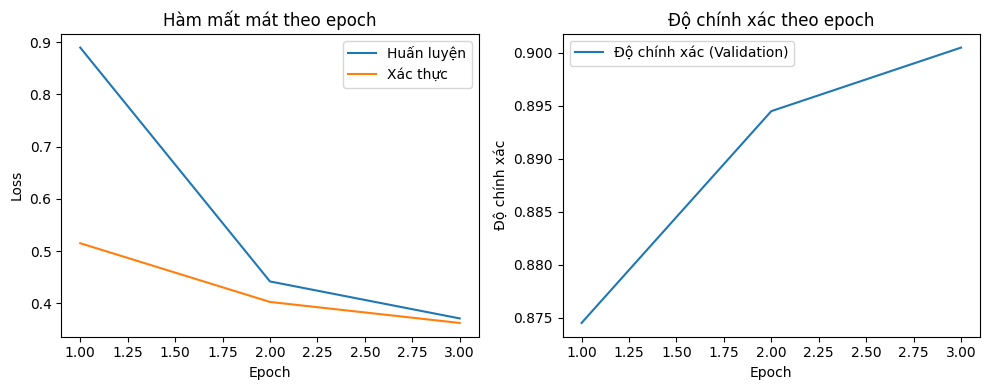

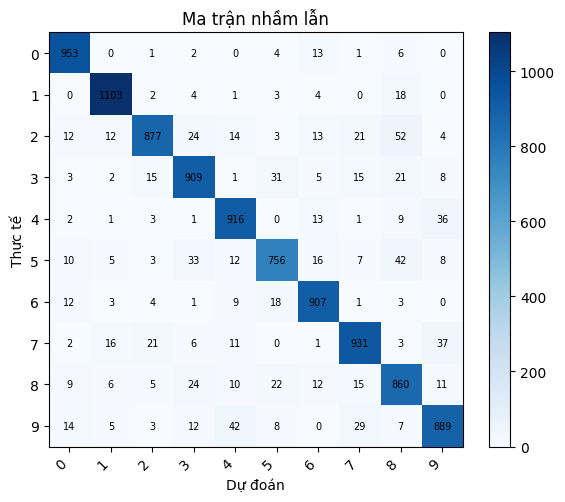


===== Huấn luyện mlp (epochs=4) =====
Epoch 01: train_loss=0.3823 val_loss=0.1916 val_acc=0.9428 time=6.0s
Epoch 02: train_loss=0.1365 val_loss=0.1253 val_acc=0.9615 time=7.0s
Epoch 03: train_loss=0.0867 val_loss=0.1192 val_acc=0.9647 time=6.1s
Epoch 04: train_loss=0.0650 val_loss=0.0937 val_acc=0.9710 time=6.9s


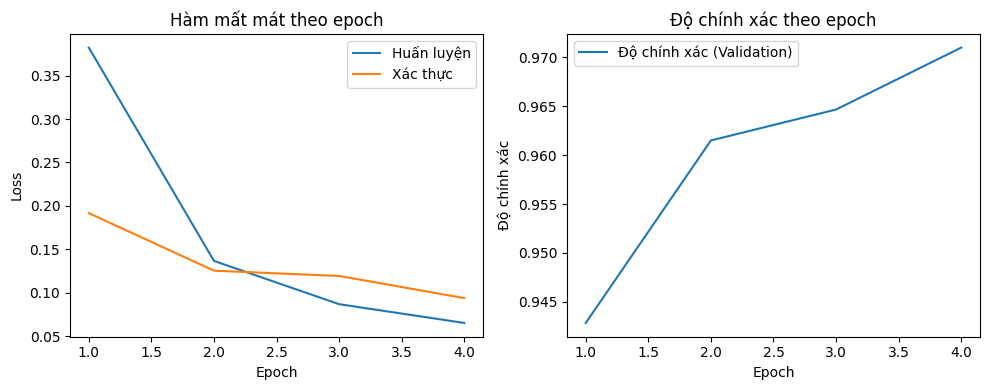

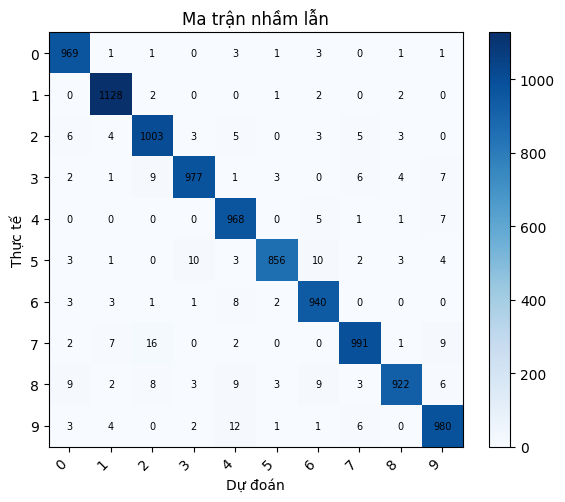


===== Huấn luyện cnn (epochs=5) =====
Epoch 01: train_loss=0.8754 val_loss=0.5565 val_acc=0.8378 time=8.6s
Epoch 02: train_loss=0.2169 val_loss=0.3286 val_acc=0.9127 time=7.6s
Epoch 03: train_loss=0.1389 val_loss=0.2177 val_acc=0.9393 time=8.3s
Epoch 04: train_loss=0.1078 val_loss=0.2536 val_acc=0.9208 time=7.5s
Epoch 05: train_loss=0.0887 val_loss=0.3767 val_acc=0.8832 time=8.2s


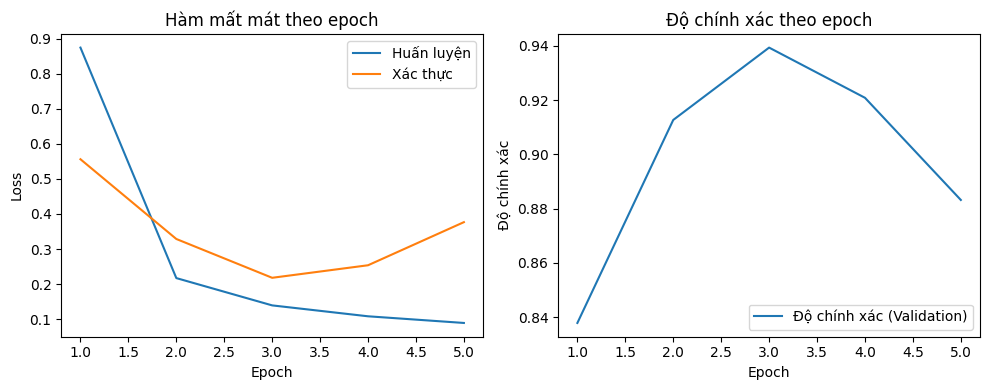

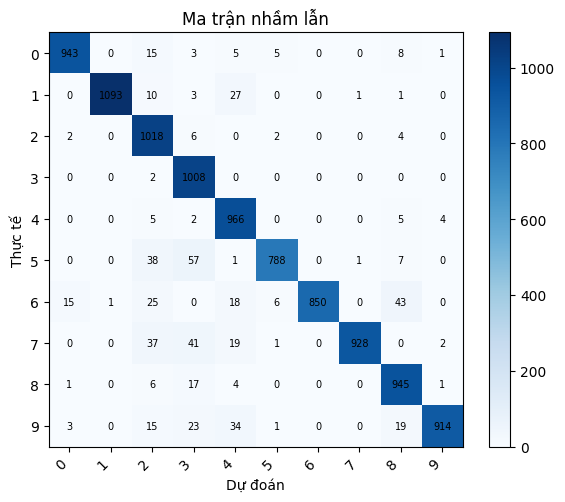


===== Huấn luyện vit (epochs=5) =====


/tmp/ipykernel_9293/3837028852.py:41: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder=nn.TransformerEncoder(enc_layer, num_layers=depth)


Epoch 01: train_loss=1.4159 val_loss=0.6070 val_acc=0.8078 time=23.5s
Epoch 02: train_loss=0.4409 val_loss=0.3667 val_acc=0.8875 time=23.6s
Epoch 03: train_loss=0.3073 val_loss=0.2557 val_acc=0.9235 time=24.0s
Epoch 04: train_loss=0.2553 val_loss=0.2058 val_acc=0.9375 time=24.3s
Epoch 05: train_loss=0.2191 val_loss=0.1792 val_acc=0.9448 time=24.5s


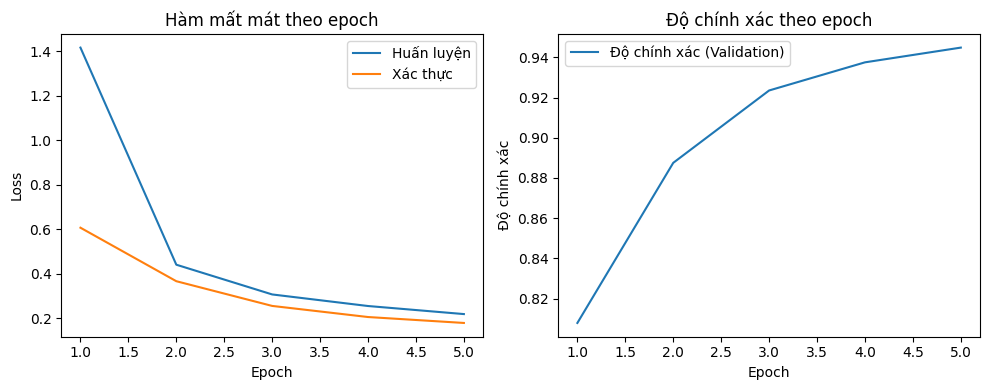

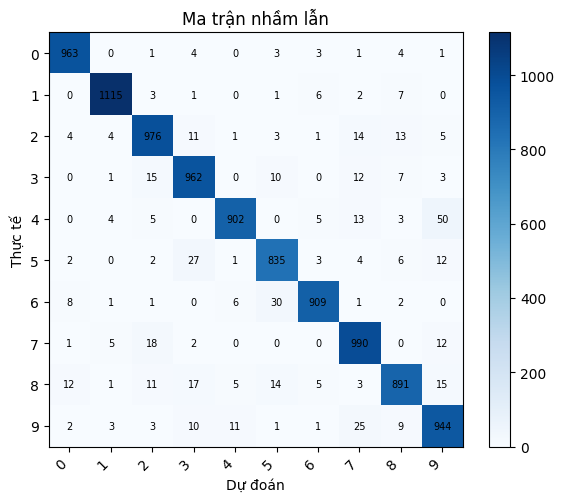


===== Huấn luyện vit_scratch (epochs=5) =====
Epoch 01: train_loss=1.4240 val_loss=0.5390 val_acc=0.8213 time=23.0s
Epoch 02: train_loss=0.4325 val_loss=0.3185 val_acc=0.8970 time=23.6s
Epoch 03: train_loss=0.3208 val_loss=0.2594 val_acc=0.9210 time=23.8s
Epoch 04: train_loss=0.2680 val_loss=0.2279 val_acc=0.9302 time=23.8s
Epoch 05: train_loss=0.2374 val_loss=0.2105 val_acc=0.9337 time=24.0s


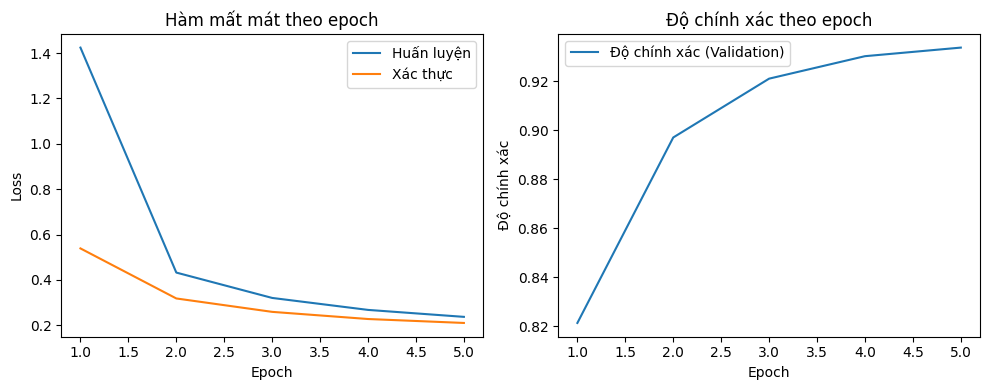

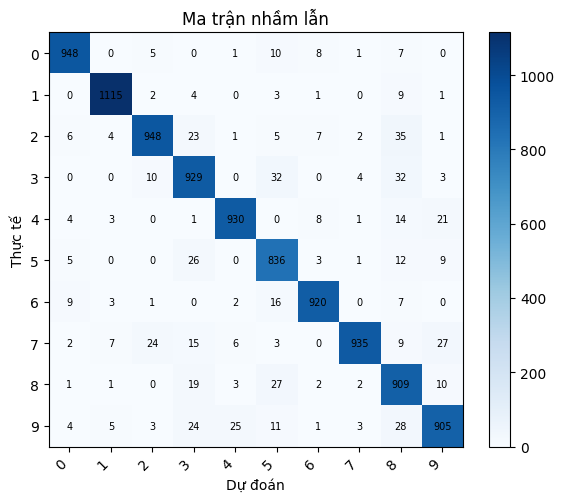


===== Huấn luyện cnn_trans (epochs=5) =====


/tmp/ipykernel_9293/3837028852.py:102: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  enc=nn.TransformerEncoderLayer(d_model, heads, d_model*4, 0.1, batch_first=True, norm_first=True); self.encoder=nn.TransformerEncoder(enc, layers)


Epoch 01: train_loss=1.5231 val_loss=0.5220 val_acc=0.8325 time=22.1s
Epoch 02: train_loss=0.2675 val_loss=0.2038 val_acc=0.9387 time=21.7s
Epoch 03: train_loss=0.1482 val_loss=0.1391 val_acc=0.9563 time=21.9s
Epoch 04: train_loss=0.1082 val_loss=0.1057 val_acc=0.9662 time=21.8s
Epoch 05: train_loss=0.0893 val_loss=0.0796 val_acc=0.9757 time=21.9s


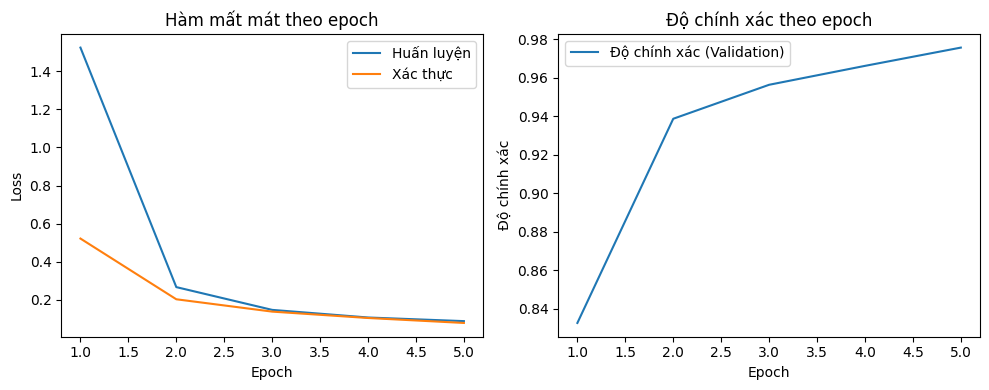

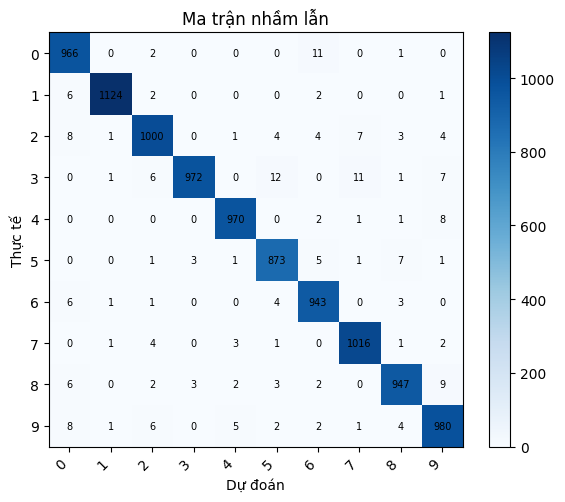


===== Huấn luyện rnn_lstm (epochs=4) =====
Epoch 01: train_loss=0.7377 val_loss=0.2908 val_acc=0.9087 time=7.7s
Epoch 02: train_loss=0.1683 val_loss=0.1186 val_acc=0.9638 time=6.8s
Epoch 03: train_loss=0.1091 val_loss=0.0981 val_acc=0.9700 time=7.3s
Epoch 04: train_loss=0.0799 val_loss=0.0808 val_acc=0.9757 time=7.7s


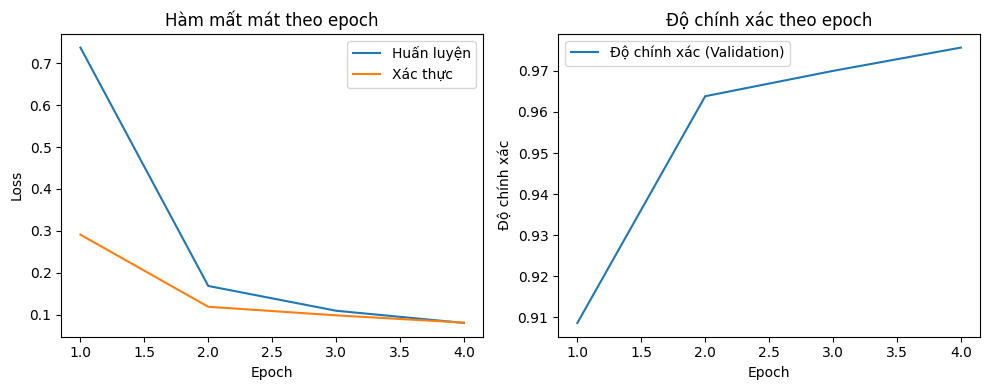

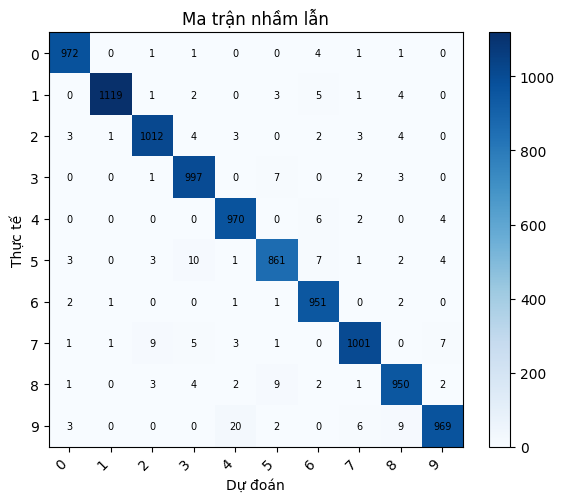


===== Huấn luyện rnn_gru (epochs=4) =====
Epoch 01: train_loss=0.6508 val_loss=0.2391 val_acc=0.9257 time=6.8s
Epoch 02: train_loss=0.1774 val_loss=0.1259 val_acc=0.9630 time=7.6s
Epoch 03: train_loss=0.1103 val_loss=0.1061 val_acc=0.9690 time=6.7s
Epoch 04: train_loss=0.0849 val_loss=0.0795 val_acc=0.9765 time=7.4s


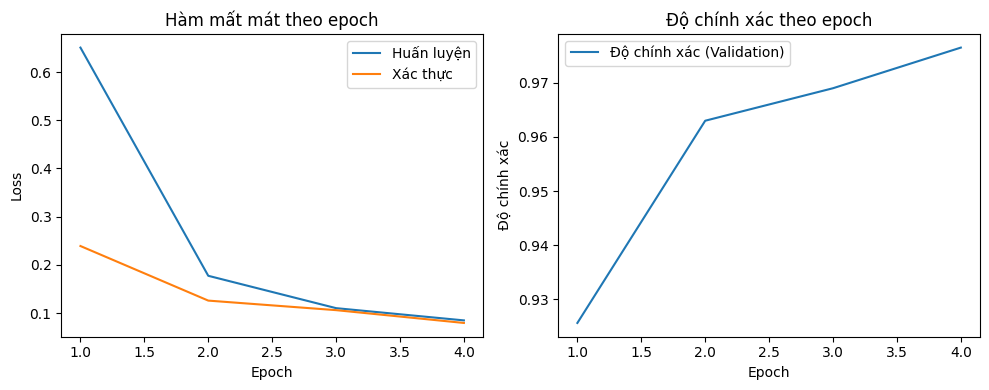

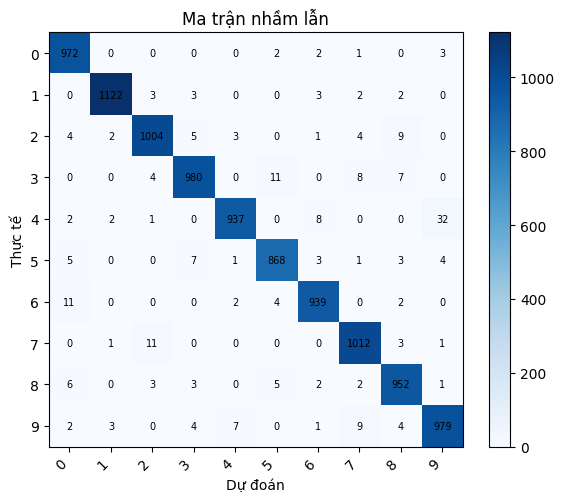

,run,model,test_acc,test_loss
6,mnist_rnn_lstm_1775055038,rnn_lstm,0.9802,0.064557
5,mnist_cnn_trans_1775054926,cnn_trans,0.9791,0.062703
7,mnist_rnn_gru_1775055070,rnn_gru,0.9765,0.074606
1,mnist_mlp_1775054612,mlp,0.9734,0.085319
3,mnist_vit_1775054682,vit,0.9487,0.158851
2,mnist_cnn_1775054640,cnn,0.9453,0.210587
4,mnist_vit_scratch_1775054805,vit_scratch,0.9375,0.201243
0,mnist_softmax_1775054587,softmax,0.9101,0.338410


In [ ]:
summary = []
for name, ep in [('softmax',3), ('mlp',4), ('cnn',5), ('vit',5), ('vit_scratch',5), ('cnn_trans',5), ('rnn_lstm',4), ('rnn_gru',4)]:
    run, m = train_and_report(name, epochs=ep, lr=1e-3)
    summary.append({'run': run.name, 'model': name, 'test_acc': m['acc'], 'test_loss': m['loss']})
import pandas as pd
df = pd.DataFrame(summary)
df.sort_values('test_acc', ascending=False)


In [ ]:
import pandas as pd
summary_csv = RESULTS/'summary.csv'
try:
    df.to_csv(summary_csv, index=False)
    print('Đã lưu bảng tổng hợp:', summary_csv)
except NameError:
    print('Chưa có df (hãy chạy cell thí nghiệm).')


Đã lưu bảng tổng hợp: results/summary.csv
